# 19 — Pooling and Spatial Downsampling

Pooling summarizes local neighborhoods independently in each channel. Unlike convolution, it has no learned weights or biases. Its main architectural role is to reduce spatial resolution and enlarge the effective receptive field of later features.

## Learning objectives

- calculate pooling output dimensions;
- implement a naive max-pooling forward pass;
- explain why pooling preserves channel count;
- route gradients through the selected maxima;
- accumulate gradients for overlapping pooling windows;
- understand ties and nondifferentiable points;
- compare max pooling, average pooling, and strided convolution.

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.gradient_check import (
    eval_numerical_gradient_array,
    relative_error,
)

np.set_printoptions(precision=3, suppress=True)

## 1. Pooling geometry

For NCHW input $X:(N,C,H,W)$, a pooling window has spatial size $(PH,PW)$ and moves with stride $S$. With no padding,

$$
H_{out}=1+\left\lfloor\frac{H-PH}{S}\right\rfloor,
$$

$$
W_{out}=1+\left\lfloor\frac{W-PW}{S}\right\rfloor.
$$

Pooling operates on every channel independently, so its output shape is

$$
Y:(N,C,H_{out},W_{out}).
$$

The channel count remains $C$: pooling does not combine channels or create new feature detectors.

### Exercise 1 — Calculate pooling shapes

Complete the helper. Require the windows to tile the input exactly, as we did for convolution. Then calculate the shapes for a standard non-overlapping pool and an overlapping pool.

In [10]:
def pooling_output_shape(
    input_height, input_width, pool_height, pool_width, stride
):
    """Return spatial output shape for exactly tiled pooling."""
    for name, value in (
        ("input_height", input_height),
        ("input_width", input_width),
        ("pool_height", pool_height),
        ("pool_width", pool_width),
        ("stride", stride),
    ):
        if isinstance(value, (bool, np.bool_)) or not isinstance(
            value, (int, np.integer)
        ):
            raise TypeError(f"{name} must be an integer")
        if value <= 0:
            raise ValueError(f"{name} must be positive")

    # Calculate how far the window can travel before applying stride.
    height_travel = input_height - pool_height
    width_travel = input_width - pool_width

    # Reject impossible windows and incomplete tiling. Travel zero is valid:
    # it means the pooling window fits exactly once.
    if height_travel < 0 or width_travel < 0:
        raise ValueError("pooling window cannot be larger than the input")
    if height_travel % stride != 0 or width_travel % stride != 0:
        raise ValueError("pooling windows must tile the input exactly")

    # include the initial window position.
    return 1 + height_travel // stride, 1 + width_travel // stride


assert pooling_output_shape(8, 8, 2, 2, stride=2) == (4, 4)
assert pooling_output_shape(5, 5, 3, 3, stride=1) == (3, 3)
print("Pooling shape checks passed.")

Pooling shape checks passed.


In [11]:
not isinstance(True, (int, np.integer)), not isinstance(1, (int, np.integer)), not isinstance('1', (int, np.integer))

(False, False, True)

## 2. Max-pooling forward pass

At one example, channel, and output position, max pooling selects the largest value in the corresponding spatial window:

$$
Y_{n,c,i,j}=\max_{u,v}X_{n,c,iS+u,jS+v}.
$$

$u$ and $v$ index positions inside the pooling window. Notice that there is no sum over $c$ and no filter index $f$: each input channel produces one output channel.

### Exercise 2 — Pool one window

Extract the bottom-right $2\times2$ window and calculate its maximum.

In [12]:
pool_input = np.array(
    [[1, 3, 2, 0], [4, 6, 5, 1], [7, 2, 9, 8], [3, 5, 4, 2]],
    dtype=np.float64,
)

# For pool size 2 and stride 2, output position (1, 1) starts at (2, 2).
# extract the window and select its maximum.
bottom_right_window = pool_input[2:, 2:]
pooled_value = np.max(bottom_right_window)

assert np.array_equal(bottom_right_window, [[9, 8], [4, 2]])
assert pooled_value == 9
bottom_right_window, pooled_value

(array([[9., 8.],
        [4., 2.]]),
 np.float64(9.0))

### Exercise 3 — Implement `max_pool_forward_naive`

Loop over examples, channels, output rows, and output columns. Extract one two-dimensional window and store its maximum. Cache the input and pooling configuration for the backward pass.

In [13]:
def max_pool_forward_naive(x, *, pool_height, pool_width, stride):
    """Compute a naive max-pooling forward pass for NCHW input."""
    if x.ndim != 4:
        raise ValueError("x must be four-dimensional")
    num_examples, num_channels, input_height, input_width = x.shape
    output_height, output_width = pooling_output_shape(
        input_height, input_width, pool_height, pool_width, stride
    )

    # allocate output with shape (N, C, H_out, W_out).
    output = np.zeros((num_examples, num_channels, output_height, output_width))

    for n in range(num_examples):
        for c in range(num_channels):
            for i in range(output_height):
                # calculate the input-row slice.
                input_i = i*stride
                for j in range(output_width):
                    # calculate the input-column slice.
                    input_j = j*stride
                    # extract the 2D window and store its maximum.
                    window = x[n, c, input_i:input_i+pool_height, input_j:input_j+pool_width]
                    output[n, c, i, j] = np.max(window)

    cache = (x, pool_height, pool_width, stride)
    return output, cache

### Exercise 4 — Verify batches and channels

Run non-overlapping $2\times2$ pooling on two channels, then verify that the second channel is pooled independently rather than combined with the first.

In [14]:
known_x = np.stack([pool_input, pool_input + 100], axis=0)[None, ...]
known_output, known_cache = max_pool_forward_naive(
    known_x, pool_height=2, pool_width=2, stride=2
)
expected_first_channel = np.array([[6, 5], [7, 9]])

assert known_x.shape == (1, 2, 4, 4)
assert known_output.shape == (1, 2, 2, 2)
assert np.array_equal(known_output[0, 0], expected_first_channel)
assert np.array_equal(
    known_output[0, 1], expected_first_channel + 100
)
known_output

array([[[[  6.,   5.],
         [  7.,   9.]],

        [[106., 105.],
         [107., 109.]]]])

## 3. Max-pooling backward pass

For one window with a unique maximum, changing a non-maximum value slightly does not change the pooled output. Changing the maximum does. The local derivative is therefore 1 at the winning position and 0 elsewhere.

If the upstream scalar is $g$, backward propagation routes $g$ to the winner:

$$
dX[\text{window}]\mathrel{+}=gM,
$$

where mask $M$ is one at the selected maximum and zero elsewhere. We use `+=` because pooling windows may overlap.

### Exercise 5 — Route one upstream gradient

Create a mask selecting the maximum of the window and route upstream value `3.5` only to that position.

In [15]:
backward_window = np.array([[1.0, 4.0], [2.0, 3.0]])
window_upstream = 3.5

# make a Boolean mask and multiply it by the upstream scalar.
maximum_mask = backward_window == backward_window.max()
window_gradient = window_upstream * maximum_mask

assert np.array_equal(maximum_mask, [[False, True], [False, False]])
assert np.array_equal(window_gradient, [[0.0, 3.5], [0.0, 0.0]])
window_gradient

array([[0. , 3.5],
       [0. , 0. ]])

### Ties between maxima

Max is not differentiable when several entries share the largest value. A backward implementation must choose a convention. In this notebook, `np.argmax` selects the **first maximum in flattened row-major order**, and the full upstream gradient goes to that one position.

Another implementation might distribute the gradient among tied maxima. Neither convention is the unique derivative at a tie because an ordinary derivative does not exist there. Numerical gradient checks should use inputs with unique maxima away from these points.

### Exercise 6 — Implement `max_pool_backward_naive`

Use `np.argmax` and `np.unravel_index` to locate one winning row and column in each forward window. Add the corresponding upstream value to that input coordinate.

In [16]:
def max_pool_backward_naive(dout, cache):
    """Backpropagate through a naive max-pooling layer."""
    x, pool_height, pool_width, stride = cache
    num_examples, num_channels, input_height, input_width = x.shape
    output_height, output_width = pooling_output_shape(
        input_height, input_width, pool_height, pool_width, stride
    )
    expected_shape = (num_examples, num_channels, output_height, output_width)
    if dout.shape != expected_shape:
        raise ValueError(f"dout must have shape {expected_shape}")

    gradient_dtype = np.result_type(x.dtype, dout.dtype, np.float32)
    dx = np.zeros(x.shape, dtype=gradient_dtype)

    for n in range(num_examples):
        for c in range(num_channels):
            for i in range(output_height):
                h_start = i * stride
                h_end = h_start + pool_height
                for j in range(output_width):
                    w_start = j * stride
                    w_end = w_start + pool_width
                    window = x[n, c, h_start:h_end, w_start:w_end]

                    # find the first maximum's local row and column.
                    flat_index = np.argmax(window)
                    local_row, local_col = np.unravel_index(flat_index, window.shape)

                    # map local coordinates back to x and accumulate.
                    dx[n, c, h_start + local_row, w_start + local_col] += dout[n, c, i, j]

    return dx

### Exercise 7 — Test overlap and numerical gradients

First use four overlapping windows that all select the center value. Then numerically check a random input with unique maxima.

In [17]:
overlap_x = np.array(
    [[[[1.0, 2.0, 3.0], [4.0, 9.0, 6.0], [7.0, 8.0, 5.0]]]]
)
overlap_output, overlap_cache = max_pool_forward_naive(
    overlap_x, pool_height=2, pool_width=2, stride=1
)
overlap_dx = max_pool_backward_naive(np.ones_like(overlap_output), overlap_cache)
expected_overlap_dx = np.zeros_like(overlap_x)
expected_overlap_dx[0, 0, 1, 1] = 4.0
assert np.array_equal(overlap_dx, expected_overlap_dx)

generator = np.random.default_rng(19)
check_x = generator.normal(size=(2, 2, 4, 4))
check_output, check_cache = max_pool_forward_naive(
    check_x, pool_height=2, pool_width=2, stride=2
)
check_dout = generator.normal(size=check_output.shape)
analytical_dx = max_pool_backward_naive(check_dout, check_cache)

# numerically differentiate the pooling output with respect to its input.
numerical_dx = eval_numerical_gradient_array(
    lambda canditate_x: max_pool_forward_naive(canditate_x, pool_height=2, pool_width=2, stride=2)[0],
    check_x,
    check_dout
)
error = relative_error(analytical_dx, numerical_dx)
print("dx relative error:", error)
assert error < 1e-8

dx relative error: 3.275633380665387e-12


## 4. Visualize downsampling

The synthetic feature map below contains a broad bright region and a few isolated peaks. Compare non-overlapping max pooling with average pooling. Max pooling preserves the strongest response in each window; average pooling summarizes all values.

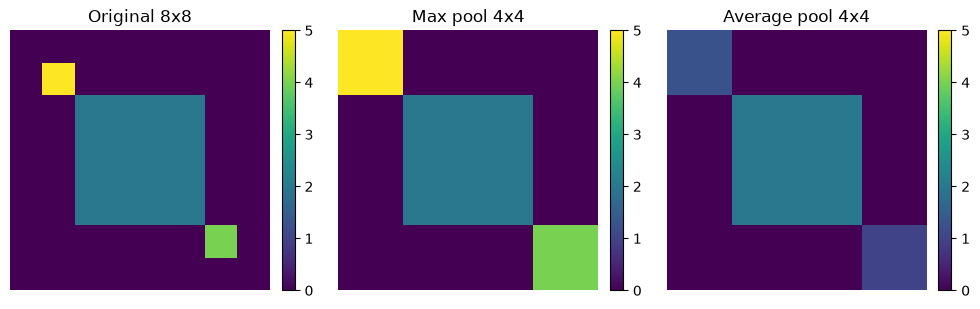

In [18]:
feature_map = np.zeros((8, 8), dtype=np.float64)
feature_map[2:6, 2:6] = 2.0
feature_map[1, 1] = 5.0
feature_map[6, 6] = 4.0
feature_batch = feature_map[None, None, :, :]
max_downsampled, _ = max_pool_forward_naive(
    feature_batch, pool_height=2, pool_width=2, stride=2
)
average_downsampled = feature_map.reshape(4, 2, 4, 2).mean(axis=(1, 3))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
arrays = (feature_map, max_downsampled[0, 0], average_downsampled)
titles = ("Original 8x8", "Max pool 4x4", "Average pool 4x4")
for axis, array, title in zip(axes, arrays, titles):
    image = axis.imshow(array, cmap="viridis", vmin=0, vmax=5)
    axis.set_title(title)
    axis.axis("off")
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Exercise 8 — Compare downsampling methods

Add a short Markdown cell answering:

1. Which information does max pooling preserve and discard?
2. Which information does average pooling preserve and discard?
3. Why is strided convolution different from both?
4. Why can aggressive downsampling harm image classification?

1. Max pooling preserves the strongest activation in each window but discards the other values and their exact arrangement.
2. Average pooling preserves the local mean but smooths peaks and discards the individual values and their arrangement.
3. Strided convolution performs learned weighted combinations and can change channel count; max and average pooling use fixed rules independently in each channel.
4. Aggressive downsampling can remove small objects, edges, and precise spatial relationships before later layers have encoded them.

## Reflection

Add a Markdown cell answering:

1. Why does pooling preserve the number of channels?
2. What does one max-pooled output value represent?
3. Why does max-pooling backward send gradient only to the selected maximum?
4. Why is `+=` needed when pooling windows overlap?
5. What happens to the gradient at non-maximum positions?
6. Why is max pooling nondifferentiable at ties?
7. Which tie convention does this notebook use?
8. Why should numerical gradient checks avoid tied maxima?
9. How do pool size and stride affect spatial resolution?
10. How does pooling affect the receptive field of later features?
11. What is the main difference between fixed pooling and strided convolution?
12. Which pooling concept is still least clear?

After this notebook, max-pooling forward and backward functions can be added to `cs231n_practice/cnn_layers.py` and tested alongside convolution.

1. Pooling processes each channel independently, so every input channel produces one output channel.
2. One output is the largest activation inside one channel's local spatial window.
3. With a unique maximum, only changing the winning input changes the output locally, so only it receives the upstream gradient.
4. An input can be the selected maximum in several overlapping windows, so contributions from all those paths must be added.
5. Non-maximum positions receive zero gradient from that pooling window.
6. At a tie, a small perturbation can change which input is selected, so there is no unique ordinary derivative.
7. `np.argmax` selects the first maximum in flattened row-major order and routes the complete gradient there.
8. Centered finite differences near a tie may select different winners on the two sides and disagree with the chosen analytical convention.
9. Larger windows summarize larger regions, while larger strides evaluate fewer positions and reduce spatial resolution more quickly.
10. Downsampling increases the spacing between later features, so subsequent operations cover larger regions of the original input.
11. Pooling applies a fixed maximum or average rule; strided convolution learns its weights and can create a different number of channels.
12. Tie behavior is the least intuitive part because max pooling has no unique derivative when several values are equal.